In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv('/content/owid-co2-data.csv')
df.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df = df[['country', 'year', 'co2', 'co2_per_capita', 'energy_per_capita', 'gdp']]
df = df.dropna()
df = df[df['year'] == df['year'].max()]
print(df.describe())

         year           co2  co2_per_capita  energy_per_capita           gdp
count    96.0     96.000000       96.000000          96.000000  9.600000e+01
mean   2022.0    239.341885        4.017823       22244.928083  7.984893e+11
std       0.0   1229.736811        4.547430       29031.048634  3.013909e+12
min    2022.0      0.165000        0.058000         307.098000  6.750980e+08
25%    2022.0      6.042000        0.792250        3052.091750  3.141502e+10
50%    2022.0     18.249000        2.696500       11912.599500  8.344138e+10
75%    2022.0     61.657250        5.576000       31236.179250  3.382836e+11
max    2022.0  11711.808000       25.242000      167531.625000  2.696602e+13


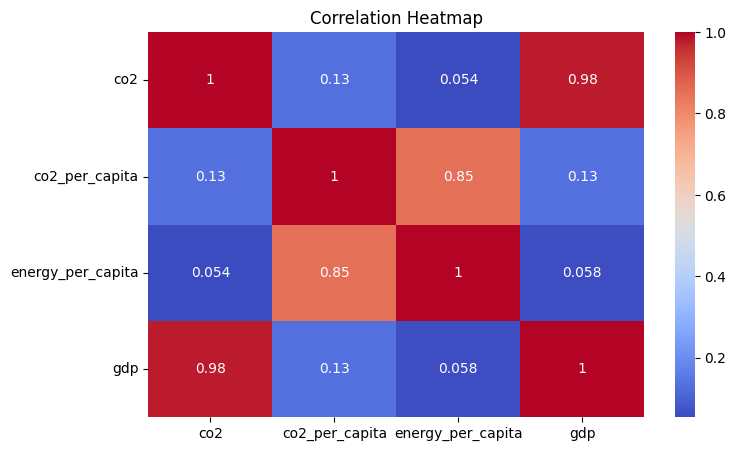

In [5]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['co2','co2_per_capita','energy_per_capita','gdp']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

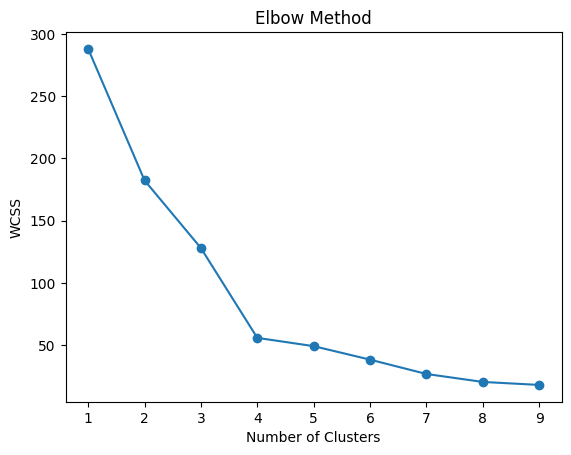

In [6]:
X = df[['co2_per_capita', 'energy_per_capita', 'gdp']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

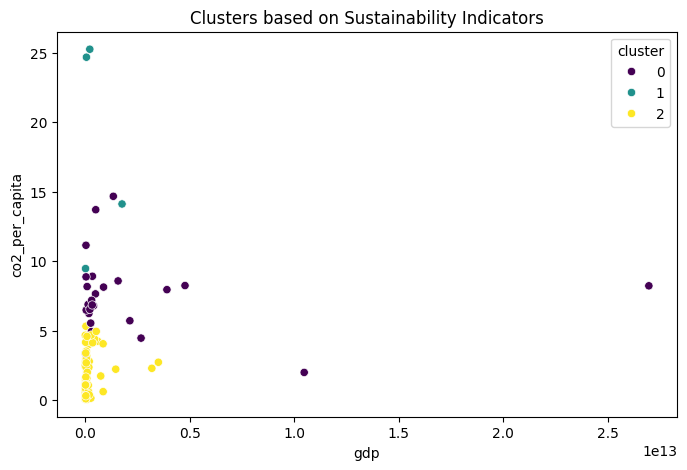

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['gdp'], y=df['co2_per_capita'], hue=df['cluster'], palette='viridis')
plt.title("Clusters based on Sustainability Indicators")
plt.show()

In [11]:
score = silhouette_score(X_scaled, df['cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.5543733953143343


In [ ]:
"""
1. Countries are grouped based on energy use, GDP, and emissions.
2. High GDP countries generally fall into high emission clusters.
3. Developing countries form a low emission cluster.
4. Strong correlation between energy consumption and CO2 emissions.
5. Clustering helps identify sustainability patterns across countries.
"""